# CCAM raw vs temperature-calibrated probability sampling

This notebook compares two respondent-level sampling pipelines for the Qwen3.6-27B CCAM run:

1. **Raw sampling:** one categorical response per persona and item from the reported probabilities ($T=1$).
2. **Calibrated sampling:** the same one-draw pipeline after one global, cross-validated temperature transformation.

Both arms use identical uniform random draws, so differences are caused by temperature scaling rather than unrelated random-number variation. This design evaluates the value of calibration; it does **not** compare sampling with an analytic probability-mixture estimator.

The primary evaluation is leave-one-CCAM-wave-out. A final temperature fitted to every wave is also reported as a descriptive, deployable parameter. Human targets use CCAM survey weights. The benchmark definitions motivating the analysis are documented in the [Silicon Sample Benchmark comparison functions](https://janpfander.github.io/llm_predictions_megastudy/preregistration_benchmark.html#sec-comparison-functions).


In [1]:
from pathlib import Path
import gc
import json
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.optimize import minimize_scalar

def find_repository_root(start=None):
    candidate = Path.cwd().resolve() if start is None else Path(start).resolve()
    for path in (candidate, *candidate.parents):
        if (path / "pyproject.toml").exists() and (path / "qstn_data").exists():
            return path
    raise RuntimeError(f"Could not find repository root from {candidate}")

ROOT = find_repository_root()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from ccam_probability.calibration import ground_truth_targets
from ccam_probability.data import (
    CCAM_WAVES,
    load_ccam_ground_truth,
    load_prediction_probabilities,
)
from ccam_probability.diagnostics import MODERATOR_COLUMNS
from ccam_probability.specs import load_ccam_specs

PARSED_PATH = ROOT / "results" / "6972" / "Qwen_Qwen3.6-27B_CCAM_probability_parsed.json"
CCAM_PATH = ROOT / "ccam_survey" / "CCAM_SPSS_Data_2008-2024.sav"
SAMPLING_SEED = 20260804
MIN_GROUP_N = 30
EPSILON = 1e-8
LOG_T_BOUNDS = (-3.0, 3.0)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 30)


## Inputs and validation

The parsed artifact is fixed to run 6972. Existing model-vector imputations are retained. The diagnostic below exposes their sources rather than silently removing them.


In [2]:
if not PARSED_PATH.exists():
    raise FileNotFoundError(PARSED_PATH)
if not CCAM_PATH.exists():
    raise FileNotFoundError(CCAM_PATH)

specs = load_ccam_specs(ROOT)
predictions = load_prediction_probabilities(PARSED_PATH, specs)
ground_truth = load_ccam_ground_truth(CCAM_PATH, specs)
targets = ground_truth_targets(ground_truth, specs)

with PARSED_PATH.open(encoding="utf-8") as handle:
    parsed_payload = json.load(handle)
validation_payload = parsed_payload["validation"]
source_counts = pd.Series(
    [
        item_result["source"]
        for record in parsed_payload["records"]
        for item_result in record["resolved_probabilities"].values()
    ],
    name="vectors",
).value_counts().rename_axis("source").reset_index()
del parsed_payload
gc.collect()

assert len(predictions.personas) == 18_000
assert len(specs) == 20
assert tuple(sorted(ground_truth.wave.unique())) == CCAM_WAVES
assert len(targets) == 187

probability_checks = []
for item_id, values in predictions.probabilities.items():
    probability_checks.append(
        {
            "item_id": item_id,
            "n_personas": len(values),
            "minimum": float(values.min()),
            "maximum_sum_error": float(np.max(np.abs(values.sum(axis=1) - 1))),
        }
    )
probability_checks = pd.DataFrame(probability_checks)
assert (probability_checks.minimum >= 0).all()
assert (probability_checks.maximum_sum_error < 1e-6).all()

input_summary = pd.DataFrame(
    {
        "quantity": [
            "Synthetic personas",
            "CCAM respondents",
            "CCAM waves",
            "CCAM items",
            "Observed item × wave cells",
            "Complete valid model responses",
            "Responses requiring imputation",
        ],
        "value": [
            len(predictions.personas),
            len(ground_truth),
            ground_truth.wave.nunique(),
            len(specs),
            len(targets),
            validation_payload["complete_valid_responses"],
            validation_payload["responses_requiring_imputation"],
        ],
    }
)
display(input_summary)
display(source_counts)
display(
    targets.pivot(index="item_id", columns="wave", values="n")
    .style.format(na_rep="—", precision=0)
    .set_caption("Available human responses by CCAM item and wave")
)

human_scores = ground_truth[
    [
        "wave",
        "weight_wave",
        "weight_aggregate",
        "gender_h",
        "age_band_h",
        "race_h",
        "education_h",
        "income_h",
        "party_h",
    ]
].copy()

for item_id, spec in specs.items():
    score_map = dict(zip(spec.codes, np.asarray(spec.scores) * 100, strict=True))
    human_scores[item_id] = ground_truth[item_id].map(score_map).astype(float)

synthetic_base = predictions.personas[
    [
        "persona_id",
        "gender_h",
        "age_band_h",
        "race_h",
        "education_h",
        "income_h",
        "party_h",
    ]
].copy()


,quantity,value
0,Synthetic personas,18000
1,CCAM respondents,10299
2,CCAM waves,10
3,CCAM items,20
4,Observed item × wave cells,187
5,Complete valid model responses,17848
6,Responses requiring imputation,152


,source,count
0,model,359101
1,global_mean,899


wave,22,23,24,25,26,27,28,29,30,31
item_id,,,,,,,,,,
cause_recoded,1028,1033,1037,1005,1018,1083,1010,1032,1031,1010
discuss_GW,1028,1035,1037,1006,1018,1083,1011,1032,1031,1012
fund_research,1024,1027,1024,991,1012,1076,1003,—,—,1008
generate_renewable,1025,1027,—,—,1011,1075,—,1023,1026,1009
happening,1029,1034,1037,1006,1018,1085,1010,1032,1031,1012
harm_US,1029,1036,1035,1006,1018,1085,1010,1032,1031,1013
harm_dev_countries,1029,1035,1034,1006,1018,1085,1009,1032,1031,1013
harm_future_gen,1029,1035,1035,1006,1018,1085,1010,1031,1031,1013
harm_personally,1029,1035,1035,1006,1018,1085,1010,1032,1031,1013


## Benchmark evaluation availability

CCAM provides repeated baseline surveys, not randomized message conditions. Consequently, treatment-effect evaluations cannot be reconstructed from this artifact and are not replaced with wave-based pseudo-effects.


In [3]:
availability = pd.DataFrame(
    [
        ("ATE recovery", False, "No treatment condition in the CCAM prediction artifact."),
        ("ATE calibration regression", False, "No predicted or human treatment-effect pairs."),
        ("Condition × moderator heterogeneity", False, "No treatment assignment or interactions."),
        ("Overall response distributions", True, "Applied to held-out CCAM waves."),
        ("Within-subgroup distributions", True, "Applied to harmonized demographic groups."),
        ("Demographic baseline calibration", True, "Applied to weighted human and unweighted synthetic group means."),
        ("Demographic predictability / stereotyping", True, "Moderator main effects; no condition fixed effect is available."),
    ],
    columns=["evaluation", "available", "reason"],
)
display(availability.style.hide(axis="index"))


evaluation,available,reason
ATE recovery,False,No treatment condition in the CCAM prediction artifact.
ATE calibration regression,False,No predicted or human treatment-effect pairs.
Condition × moderator heterogeneity,False,No treatment assignment or interactions.
Overall response distributions,True,Applied to held-out CCAM waves.
Within-subgroup distributions,True,Applied to harmonized demographic groups.
Demographic baseline calibration,True,Applied to weighted human and unweighted synthetic group means.
Demographic predictability / stereotyping,True,Moderator main effects; no condition fixed effect is available.


## Global temperature fitting

Temperature scaling uses $\mathrm{softmax}(\log(p+\epsilon)/T)$. The $T=1$ branch returns the normalized input exactly. Each fold minimizes mean categorical cross-entropy on the other nine waves; targets within a wave are survey weighted.


held_out_wave,temperature,raw_cross_entropy,calibrated_cross_entropy,cross_entropy_improvement,at_boundary
22,1.4211,1.3520,1.3464,0.0056,False
23,1.4098,1.3650,1.3547,0.0103,False
24,1.3967,1.4021,1.3868,0.0153,False
25,1.4233,1.3483,1.3436,0.0048,False
26,1.4072,1.3789,1.3682,0.0107,False
27,1.3915,1.3956,1.3786,0.0170,False
28,1.4097,1.3798,1.3700,0.0099,False
29,1.4017,1.3931,1.3799,0.0132,False
30,1.4045,1.3953,1.3831,0.0122,False
31,1.3992,1.3824,1.3681,0.0143,False


Final all-wave temperature: 1.4064
Mean held-out cross-entropy improvement: 0.01132


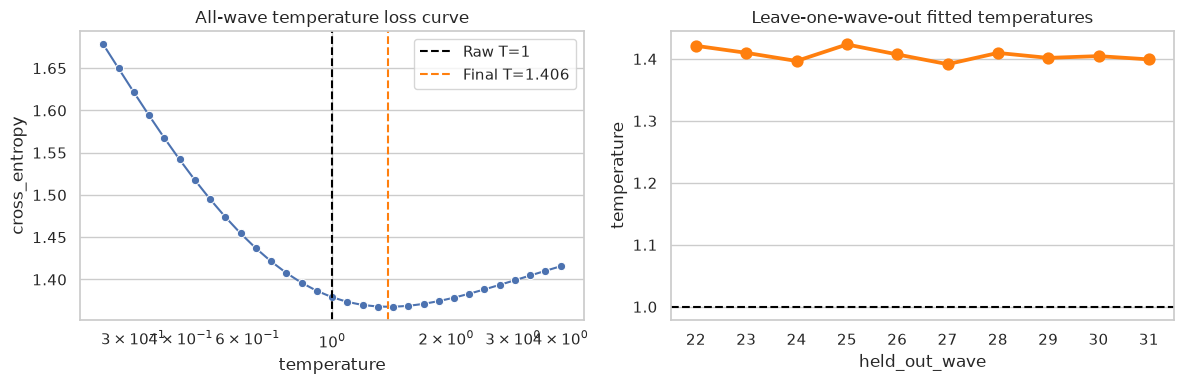

In [4]:
def temperature_scale(probabilities, temperature):
    values = np.asarray(probabilities, dtype=float)
    if not np.isfinite(temperature) or temperature <= 0:
        raise ValueError("temperature must be positive and finite")
    if values.ndim not in (1, 2) or np.any(values < 0) or not np.all(np.isfinite(values)):
        raise ValueError("probabilities must be finite and non-negative")
    totals = values.sum(axis=-1, keepdims=True)
    if np.any(totals <= 0):
        raise ValueError("probability vectors must have positive mass")
    normalized = values / totals
    if temperature == 1.0:
        return normalized.copy()
    logits = np.log(normalized + EPSILON) / temperature
    logits -= logits.max(axis=-1, keepdims=True)
    scaled = np.exp(logits)
    return scaled / scaled.sum(axis=-1, keepdims=True)

def predicted_shares(temperature):
    return {
        item_id: temperature_scale(values, temperature).mean(axis=0)
        for item_id, values in predictions.probabilities.items()
    }

def categorical_cross_entropy(target, prediction):
    target = np.asarray(target, dtype=float)
    prediction = np.asarray(prediction, dtype=float)
    return float(-np.sum(target * np.log(np.clip(prediction, EPSILON, 1))))

def temperature_loss(target_frame, temperature):
    shares = predicted_shares(temperature)
    losses = [
        categorical_cross_entropy(row.shares, shares[row.item_id])
        for row in target_frame.itertuples(index=False)
    ]
    if not losses:
        raise ValueError("No item-wave targets available")
    return float(np.mean(losses))

def fit_temperature(target_frame):
    result = minimize_scalar(
        lambda log_temperature: temperature_loss(target_frame, float(np.exp(log_temperature))),
        bounds=LOG_T_BOUNDS,
        method="bounded",
        options={"xatol": 1e-4},
    )
    if not result.success:
        raise RuntimeError(result.message)
    log_temperature = float(result.x)
    return {
        "temperature": float(np.exp(log_temperature)),
        "log_temperature": log_temperature,
        "training_cross_entropy": float(result.fun),
        "at_boundary": bool(
            min(
                abs(log_temperature - LOG_T_BOUNDS[0]),
                abs(log_temperature - LOG_T_BOUNDS[1]),
            )
            < 0.02
        ),
    }

cv_temperature_rows = []
for held_out_wave in sorted(targets.wave.unique()):
    training_targets = targets.loc[targets.wave.ne(held_out_wave)]
    held_out_targets = targets.loc[targets.wave.eq(held_out_wave)]
    fit = fit_temperature(training_targets)
    cv_temperature_rows.append(
        {
            "held_out_wave": int(held_out_wave),
            "training_waves": tuple(sorted(training_targets.wave.unique())),
            **fit,
            "raw_cross_entropy": temperature_loss(held_out_targets, 1.0),
            "calibrated_cross_entropy": temperature_loss(
                held_out_targets, fit["temperature"]
            ),
        }
    )

cv_temperatures = pd.DataFrame(cv_temperature_rows)
cv_temperatures["cross_entropy_improvement"] = (
    cv_temperatures.raw_cross_entropy - cv_temperatures.calibrated_cross_entropy
)
final_temperature_fit = fit_temperature(targets)
FINAL_TEMPERATURE = final_temperature_fit["temperature"]

if cv_temperatures.at_boundary.any() or final_temperature_fit["at_boundary"]:
    warnings.warn("At least one temperature optimum is near the configured log-temperature boundary.")

temperature_curve = pd.DataFrame(
    {
        "temperature": np.geomspace(0.25, 4.0, 31),
    }
)
temperature_curve["cross_entropy"] = temperature_curve.temperature.map(
    lambda temperature: temperature_loss(targets, float(temperature))
)

display(
    cv_temperatures[
        [
            "held_out_wave",
            "temperature",
            "raw_cross_entropy",
            "calibrated_cross_entropy",
            "cross_entropy_improvement",
            "at_boundary",
        ]
    ].style.format(precision=4).hide(axis="index")
)
print(f"Final all-wave temperature: {FINAL_TEMPERATURE:.4f}")
print(
    "Mean held-out cross-entropy improvement: "
    f"{cv_temperatures.cross_entropy_improvement.mean():.5f}"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=temperature_curve, x="temperature", y="cross_entropy", marker="o", ax=axes[0])
axes[0].axvline(1, color="black", linestyle="--", label="Raw T=1")
axes[0].axvline(FINAL_TEMPERATURE, color="tab:orange", linestyle="--", label=f"Final T={FINAL_TEMPERATURE:.3f}")
axes[0].set_xscale("log")
axes[0].set_title("All-wave temperature loss curve")
axes[0].legend()

sns.pointplot(data=cv_temperatures, x="held_out_wave", y="temperature", ax=axes[1], color="tab:orange")
axes[1].axhline(1, color="black", linestyle="--")
axes[1].set_title("Leave-one-wave-out fitted temperatures")
plt.tight_layout()
plt.show()


## Paired categorical sampling

One uniform draw is created per persona-item pair. Reusing it for every temperature provides an exact paired comparison while retaining the requested one-response-per-person sampling design.


In [5]:
sampling_rng = np.random.default_rng(SAMPLING_SEED)
shared_uniforms = {
    item_id: sampling_rng.random(len(predictions.personas))
    for item_id in specs
}

def sampled_score_frame(temperature):
    sampled = synthetic_base.copy()
    for item_id, spec in specs.items():
        probabilities = temperature_scale(
            predictions.probabilities[item_id], temperature
        )
        cumulative = np.cumsum(probabilities, axis=1)
        cumulative[:, -1] = 1.0
        indices = np.sum(
            shared_uniforms[item_id][:, None] > cumulative,
            axis=1,
        )
        score_grid = np.asarray(spec.scores, dtype=float) * 100
        sampled[item_id] = score_grid[indices]
    return sampled

raw_sample = sampled_score_frame(1.0)
assert raw_sample[list(specs)].equals(sampled_score_frame(1.0)[list(specs)])


## Weighted categorical evaluation helpers

CCAM items have only 3–6 ordered categories, so overlap is computed directly from probability masses. KS and W1 use their categorical CDFs on a common 0–100 item scale. This is the discrete analogue of the benchmark's continuous distribution comparison.


In [6]:
HARMONIZED_LEVELS = {
    "gender_h": ["Male", "Female", "Other"],
    "age_band_h": ["18-29", "30-44", "45-59", "60+"],
    "race_h": ["White", "Black", "Hispanic", "Other"],
    "education_h": [
        "Less than high school",
        "High school",
        "Some college",
        "Bachelor's degree or higher",
    ],
    "income_h": [
        "Less than $50,000",
        "$50,000 to $99,999",
        "$100,000 or more",
    ],
    "party_h": ["Republican", "Democrat", "Independent", "Other"],
}
REFERENCE_LEVELS = {
    "gender_h": "Male",
    "age_band_h": "18-29",
    "race_h": "White",
    "education_h": "Less than high school",
    "income_h": "Less than $50,000",
    "party_h": "Republican",
}

def item_score_grid(item_id):
    return np.asarray(specs[item_id].scores, dtype=float) * 100

def distribution_shares(data, item_id, weights=None):
    values = data[item_id].to_numpy(float)
    grid = item_score_grid(item_id)
    if weights is None:
        weights_array = np.ones(len(data), dtype=float)
    else:
        weights_array = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights_array) & (weights_array > 0)
    if not valid.any():
        return None
    values = values[valid]
    weights_array = weights_array[valid]
    weights_array /= weights_array.sum()
    shares = np.array(
        [weights_array[np.isclose(values, score)].sum() for score in grid],
        dtype=float,
    )
    shares /= shares.sum()
    return shares

def categorical_distribution_metrics(human_shares, synthetic_shares, scores):
    human_shares = np.asarray(human_shares, dtype=float)
    synthetic_shares = np.asarray(synthetic_shares, dtype=float)
    scores = np.asarray(scores, dtype=float)
    human_mean = float(human_shares @ scores)
    synthetic_mean = float(synthetic_shares @ scores)
    human_variance = float(human_shares @ (scores - human_mean) ** 2)
    synthetic_variance = float(
        synthetic_shares @ (scores - synthetic_mean) ** 2
    )
    human_cdf = np.cumsum(human_shares)
    synthetic_cdf = np.cumsum(synthetic_shares)
    variance_ratio = (
        synthetic_variance / human_variance if human_variance > 0 else np.nan
    )
    return {
        "human_mean": human_mean,
        "synthetic_mean": synthetic_mean,
        "mean_error": synthetic_mean - human_mean,
        "variance_ratio": variance_ratio,
        "abs_log_variance_error": (
            abs(float(np.log(variance_ratio)))
            if np.isfinite(variance_ratio) and variance_ratio > 0
            else np.nan
        ),
        "ovl": float(np.minimum(human_shares, synthetic_shares).sum()),
        "ks_d": float(np.max(np.abs(human_cdf - synthetic_cdf))),
        "w1": float(
            np.sum(np.abs(human_cdf[:-1] - synthetic_cdf[:-1]) * np.diff(scores))
        ),
    }

def evaluate_overall(human, synthetic, weight_column, arm, wave_label):
    rows = []
    human_weights = human[weight_column].to_numpy(float)
    for item_id in specs:
        human_shares = distribution_shares(human, item_id, human_weights)
        synthetic_shares = distribution_shares(synthetic, item_id)
        if human_shares is None or synthetic_shares is None:
            continue
        rows.append(
            {
                "wave": wave_label,
                "arm": arm,
                "item_id": item_id,
                "family": specs[item_id].family,
                "n_human": int(human[item_id].notna().sum()),
                "n_synthetic": int(synthetic[item_id].notna().sum()),
                **categorical_distribution_metrics(
                    human_shares, synthetic_shares, item_score_grid(item_id)
                ),
            }
        )
    return pd.DataFrame(rows)

def evaluate_subgroup_distributions(
    human, synthetic, weight_column, arm, wave_label
):
    rows = []
    for moderator, column in MODERATOR_COLUMNS.items():
        for level in HARMONIZED_LEVELS[column]:
            human_group = human.loc[human[column].eq(level)]
            synthetic_group = synthetic.loc[synthetic[column].eq(level)]
            for item_id in specs:
                n_human = int(human_group[item_id].notna().sum())
                n_synthetic = int(synthetic_group[item_id].notna().sum())
                skipped = n_human < MIN_GROUP_N or n_synthetic < MIN_GROUP_N
                row = {
                    "wave": wave_label,
                    "arm": arm,
                    "moderator": moderator,
                    "column": column,
                    "level": level,
                    "item_id": item_id,
                    "family": specs[item_id].family,
                    "n_human": n_human,
                    "n_synthetic": n_synthetic,
                    "skipped": skipped,
                    "skip_reason": (
                        f"{level} (human n={n_human}, synthetic n={n_synthetic})"
                        if skipped
                        else None
                    ),
                }
                if not skipped:
                    human_shares = distribution_shares(
                        human_group,
                        item_id,
                        human_group[weight_column].to_numpy(float),
                    )
                    synthetic_shares = distribution_shares(
                        synthetic_group, item_id
                    )
                    row.update(
                        categorical_distribution_metrics(
                            human_shares,
                            synthetic_shares,
                            item_score_grid(item_id),
                        )
                    )
                rows.append(row)
    return pd.DataFrame(rows)


In [7]:
def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    if not valid.any():
        return np.nan
    weights = weights[valid]
    weights /= weights.sum()
    return float(weights @ values[valid])

def evaluate_demographic_baselines(
    human, synthetic, weight_column, arm, wave_label
):
    rows = []
    for moderator, column in MODERATOR_COLUMNS.items():
        for item_id in specs:
            cell_rows = []
            skipped = []
            for level in HARMONIZED_LEVELS[column]:
                human_group = human.loc[human[column].eq(level)]
                synthetic_group = synthetic.loc[synthetic[column].eq(level)]
                n_human = int(human_group[item_id].notna().sum())
                n_synthetic = int(synthetic_group[item_id].notna().sum())
                human_mean = weighted_mean(
                    human_group[item_id],
                    human_group[weight_column],
                )
                synthetic_mean = (
                    float(synthetic_group[item_id].mean())
                    if n_synthetic
                    else np.nan
                )
                if np.isfinite(human_mean) and np.isfinite(synthetic_mean):
                    cell_rows.append(
                        {
                            "level": level,
                            "absolute_error": abs(synthetic_mean - human_mean),
                            "n_human": n_human,
                            "n_synthetic": n_synthetic,
                        }
                    )
                if n_human < MIN_GROUP_N or n_synthetic < MIN_GROUP_N:
                    skipped.append(
                        f"{level} (human n={n_human}, synthetic n={n_synthetic})"
                    )

            paired = pd.DataFrame(
                cell_rows,
                columns=[
                    "level", "absolute_error", "n_human", "n_synthetic"
                ],
            )
            eligible = paired.loc[
                paired.n_human.ge(MIN_GROUP_N)
                & paired.n_synthetic.ge(MIN_GROUP_N)
            ]
            if paired.empty:
                rmse = np.nan
            else:
                rmse = float(np.sqrt(np.mean(paired.absolute_error**2)))
            if eligible.empty:
                dpd = worst_error = np.nan
                worst_group = best_group = None
            else:
                worst = eligible.loc[eligible.absolute_error.idxmax()]
                best = eligible.loc[eligible.absolute_error.idxmin()]
                dpd = float(worst.absolute_error - best.absolute_error)
                worst_error = float(worst.absolute_error)
                worst_group = worst.level
                best_group = best.level
            rows.append(
                {
                    "wave": wave_label,
                    "arm": arm,
                    "moderator": moderator,
                    "item_id": item_id,
                    "family": specs[item_id].family,
                    "rmse": rmse,
                    "n_cells": len(paired),
                    "dpd": dpd,
                    "worst_abs_error": worst_error,
                    "worst_group": worst_group,
                    "best_group": best_group,
                    "n_skipped": len(skipped),
                    "groups_skipped": "; ".join(skipped) if skipped else None,
                }
            )
    return pd.DataFrame(rows)

def fit_weighted_categorical(values, groups, weights, levels, reference):
    work = pd.DataFrame(
        {"value": values, "group": groups, "weight": weights}
    ).dropna()
    work = work.loc[
        work.group.astype(str).isin(levels)
        & np.isfinite(work.weight)
        & work.weight.gt(0)
    ].copy()
    group_values = work.group.astype(str)
    coefficient_levels = [level for level in levels if level != reference]
    design = np.column_stack(
        [
            np.ones(len(work)),
            *[
                group_values.eq(level).to_numpy(float)
                for level in coefficient_levels
            ],
        ]
    )
    weights_array = work.weight.to_numpy(float)
    sqrt_weights = np.sqrt(weights_array)
    coefficients = np.linalg.lstsq(
        design * sqrt_weights[:, None],
        work.value.to_numpy(float) * sqrt_weights,
        rcond=None,
    )[0]
    fitted = design @ coefficients
    y = work.value.to_numpy(float)
    normalized_weights = weights_array / weights_array.sum()
    mean = float(normalized_weights @ y)
    total = float(normalized_weights @ (y - mean) ** 2)
    residual = float(normalized_weights @ (y - fitted) ** 2)
    r_squared = 1 - residual / total if total > 0 else np.nan
    return (
        dict(zip(coefficient_levels, coefficients[1:], strict=True)),
        float(r_squared),
        len(work),
    )

def evaluate_demographic_predictability(
    human, synthetic, weight_column, arm, wave_label
):
    coefficient_rows = []
    r_squared_rows = []
    for moderator, column in MODERATOR_COLUMNS.items():
        declared_levels = HARMONIZED_LEVELS[column]
        human_levels = set(human[column].dropna().astype(str))
        synthetic_levels = set(synthetic[column].dropna().astype(str))
        common_levels = [
            level
            for level in declared_levels
            if level in human_levels and level in synthetic_levels
        ]
        reference = REFERENCE_LEVELS[column]
        if reference not in common_levels or len(common_levels) < 2:
            continue
        for item_id in specs:
            human_coefficients, human_r2, n_human = fit_weighted_categorical(
                human[item_id],
                human[column],
                human[weight_column],
                common_levels,
                reference,
            )
            synthetic_coefficients, synthetic_r2, n_synthetic = (
                fit_weighted_categorical(
                    synthetic[item_id],
                    synthetic[column],
                    np.ones(len(synthetic)),
                    common_levels,
                    reference,
                )
            )
            r_squared_rows.append(
                {
                    "wave": wave_label,
                    "arm": arm,
                    "moderator": moderator,
                    "item_id": item_id,
                    "family": specs[item_id].family,
                    "reference_level": reference,
                    "human_r_squared": human_r2,
                    "synthetic_r_squared": synthetic_r2,
                    "r_squared_gap": synthetic_r2 - human_r2,
                    "abs_r_squared_gap": abs(synthetic_r2 - human_r2),
                    "n_human": n_human,
                    "n_synthetic": n_synthetic,
                }
            )
            for level in common_levels:
                if level == reference:
                    continue
                human_coefficient = float(human_coefficients[level])
                synthetic_coefficient = float(
                    synthetic_coefficients[level]
                )
                coefficient_rows.append(
                    {
                        "wave": wave_label,
                        "arm": arm,
                        "moderator": moderator,
                        "item_id": item_id,
                        "family": specs[item_id].family,
                        "reference_level": reference,
                        "level": level,
                        "human_coefficient": human_coefficient,
                        "synthetic_coefficient": synthetic_coefficient,
                        "coefficient_error": (
                            synthetic_coefficient - human_coefficient
                        ),
                        "absolute_coefficient_error": abs(
                            synthetic_coefficient - human_coefficient
                        ),
                    }
                )
    return pd.DataFrame(coefficient_rows), pd.DataFrame(r_squared_rows)


## Primary evaluation: held-out waves

For each wave, the calibrated arm uses only the temperature selected from the other nine waves. The raw arm is the same fixed $T=1$ sample in every fold.


In [8]:
overall_parts = []
subgroup_parts = []
baseline_parts = []
coefficient_parts = []
r_squared_parts = []

for fold in cv_temperatures.itertuples(index=False):
    held_out_human = human_scores.loc[
        human_scores.wave.eq(fold.held_out_wave)
    ].copy()
    calibrated_sample = sampled_score_frame(fold.temperature)

    for arm, sample in (
        ("raw_T1", raw_sample),
        ("calibrated_T_cv", calibrated_sample),
    ):
        overall_parts.append(
            evaluate_overall(
                held_out_human,
                sample,
                "weight_wave",
                arm,
                fold.held_out_wave,
            )
        )
        subgroup_parts.append(
            evaluate_subgroup_distributions(
                held_out_human,
                sample,
                "weight_wave",
                arm,
                fold.held_out_wave,
            )
        )
        baseline_parts.append(
            evaluate_demographic_baselines(
                held_out_human,
                sample,
                "weight_wave",
                arm,
                fold.held_out_wave,
            )
        )
        coefficients, r_squared = evaluate_demographic_predictability(
            held_out_human,
            sample,
            "weight_wave",
            arm,
            fold.held_out_wave,
        )
        coefficient_parts.append(coefficients)
        r_squared_parts.append(r_squared)

overall_cv = pd.concat(overall_parts, ignore_index=True)
subgroups_cv = pd.concat(subgroup_parts, ignore_index=True)
baselines_cv = pd.concat(baseline_parts, ignore_index=True)
coefficients_cv = pd.concat(coefficient_parts, ignore_index=True)
r_squared_cv = pd.concat(r_squared_parts, ignore_index=True)

print(
    f"Evaluated {len(overall_cv):,} overall item-wave rows, "
    f"{len(subgroups_cv):,} subgroup rows, and "
    f"{len(coefficients_cv):,} demographic coefficient pairs."
)


Evaluated 374 overall item-wave rows, 8,800 subgroup rows, and 5,680 demographic coefficient pairs.


In [9]:
def build_scorecard(overall, subgroups, baselines, coefficients, r_squared):
    rows = []
    sources = [
        (
            overall,
            {
                "Overall OVL": ("ovl", "higher"),
                "Overall KS D": ("ks_d", "lower"),
                "Overall W1 (pp)": ("w1", "lower"),
                "Overall |log variance ratio|": (
                    "abs_log_variance_error",
                    "lower",
                ),
            },
        ),
        (
            subgroups.loc[~subgroups.skipped],
            {
                "Within-subgroup OVL": ("ovl", "higher"),
                "Within-subgroup KS D": ("ks_d", "lower"),
                "Within-subgroup W1 (pp)": ("w1", "lower"),
                "Within-subgroup |log variance ratio|": (
                    "abs_log_variance_error",
                    "lower",
                ),
            },
        ),
        (
            baselines,
            {
                "Demographic baseline RMSE (pp)": ("rmse", "lower"),
                "Demographic parity gap (pp)": ("dpd", "lower"),
                "Worst-group absolute error (pp)": (
                    "worst_abs_error",
                    "lower",
                ),
            },
        ),
        (
            coefficients,
            {
                "Stereotyping coefficient MAE (pp)": (
                    "absolute_coefficient_error",
                    "lower",
                ),
            },
        ),
        (
            r_squared,
            {
                "Absolute demographic R² gap": (
                    "abs_r_squared_gap",
                    "lower",
                ),
            },
        ),
    ]
    for frame, metrics in sources:
        for metric_label, (column, orientation) in metrics.items():
            for arm, group in frame.groupby("arm"):
                rows.append(
                    {
                        "metric": metric_label,
                        "orientation": orientation,
                        "arm": arm,
                        "value": float(group[column].mean()),
                    }
                )
    long = pd.DataFrame(rows)
    wide = (
        long.pivot(
            index=["metric", "orientation"],
            columns="arm",
            values="value",
        )
        .reset_index()
        .rename_axis(columns=None)
    )
    wide["improvement"] = np.where(
        wide.orientation.eq("higher"),
        wide["calibrated_T_cv"] - wide["raw_T1"],
        wide["raw_T1"] - wide["calibrated_T_cv"],
    )
    return wide.sort_values("metric").reset_index(drop=True)

cv_scorecard = build_scorecard(
    overall_cv,
    subgroups_cv,
    baselines_cv,
    coefficients_cv,
    r_squared_cv,
)
display(
    cv_scorecard.style.format(
        {
            "raw_T1": "{:.4f}",
            "calibrated_T_cv": "{:.4f}",
            "improvement": "{:+.4f}",
        }
    ).hide(axis="index")
)


metric,orientation,calibrated_T_cv,raw_T1,improvement
Absolute demographic R² gap,lower,0.0191,0.0147,-0.0044
Demographic baseline RMSE (pp),lower,6.8442,8.0176,+1.1734
Demographic parity gap (pp),lower,5.9315,7.1083,+1.1767
Overall KS D,lower,0.1142,0.1276,+0.0134
Overall OVL,higher,0.8556,0.8497,+0.0059
Overall W1 (pp),lower,6.6577,7.7692,+1.1116
Overall |log variance ratio|,lower,0.2176,0.2892,+0.0717
Stereotyping coefficient MAE (pp),lower,5.0209,5.2080,+0.1872
Within-subgroup KS D,lower,0.1310,0.1399,+0.0089
Within-subgroup OVL,higher,0.8405,0.8360,+0.0045


## Final all-wave deployable-temperature view

This section refits $T$ on every CCAM wave and evaluates against the pooled, aggregate-weighted CCAM sample. It describes the final parameter and is not an out-of-sample performance estimate.


In [10]:
final_calibrated_sample = sampled_score_frame(FINAL_TEMPERATURE)

pooled_overall_parts = []
pooled_subgroup_parts = []
pooled_baseline_parts = []
pooled_coefficient_parts = []
pooled_r_squared_parts = []

for arm, sample in (
    ("raw_T1", raw_sample),
    ("calibrated_T_cv", final_calibrated_sample),
):
    pooled_overall_parts.append(
        evaluate_overall(
            human_scores,
            sample,
            "weight_aggregate",
            arm,
            "pooled",
        )
    )
    pooled_subgroup_parts.append(
        evaluate_subgroup_distributions(
            human_scores,
            sample,
            "weight_aggregate",
            arm,
            "pooled",
        )
    )
    pooled_baseline_parts.append(
        evaluate_demographic_baselines(
            human_scores,
            sample,
            "weight_aggregate",
            arm,
            "pooled",
        )
    )
    coefficients, r_squared = evaluate_demographic_predictability(
        human_scores,
        sample,
        "weight_aggregate",
        arm,
        "pooled",
    )
    pooled_coefficient_parts.append(coefficients)
    pooled_r_squared_parts.append(r_squared)

overall_pooled = pd.concat(pooled_overall_parts, ignore_index=True)
subgroups_pooled = pd.concat(pooled_subgroup_parts, ignore_index=True)
baselines_pooled = pd.concat(pooled_baseline_parts, ignore_index=True)
coefficients_pooled = pd.concat(pooled_coefficient_parts, ignore_index=True)
r_squared_pooled = pd.concat(pooled_r_squared_parts, ignore_index=True)

pooled_scorecard = build_scorecard(
    overall_pooled,
    subgroups_pooled,
    baselines_pooled,
    coefficients_pooled,
    r_squared_pooled,
)
display(
    pooled_scorecard.style.format(
        {
            "raw_T1": "{:.4f}",
            "calibrated_T_cv": "{:.4f}",
            "improvement": "{:+.4f}",
        }
    ).hide(axis="index")
)


metric,orientation,calibrated_T_cv,raw_T1,improvement
Absolute demographic R² gap,lower,0.0166,0.0118,-0.0048
Demographic baseline RMSE (pp),lower,6.3235,7.7049,+1.3814
Demographic parity gap (pp),lower,5.0318,6.2505,+1.2187
Overall KS D,lower,0.1102,0.1260,+0.0158
Overall OVL,higher,0.8598,0.8529,+0.0069
Overall W1 (pp),lower,6.3650,7.6266,+1.2616
Overall |log variance ratio|,lower,0.2037,0.2798,+0.0761
Stereotyping coefficient MAE (pp),lower,3.8808,3.9575,+0.0767
Within-subgroup KS D,lower,0.1234,0.1352,+0.0118
Within-subgroup OVL,higher,0.8502,0.8440,+0.0063


## Where calibration helps or hurts

Positive improvement values below mean that calibrated sampling is better under the metric's orientation.


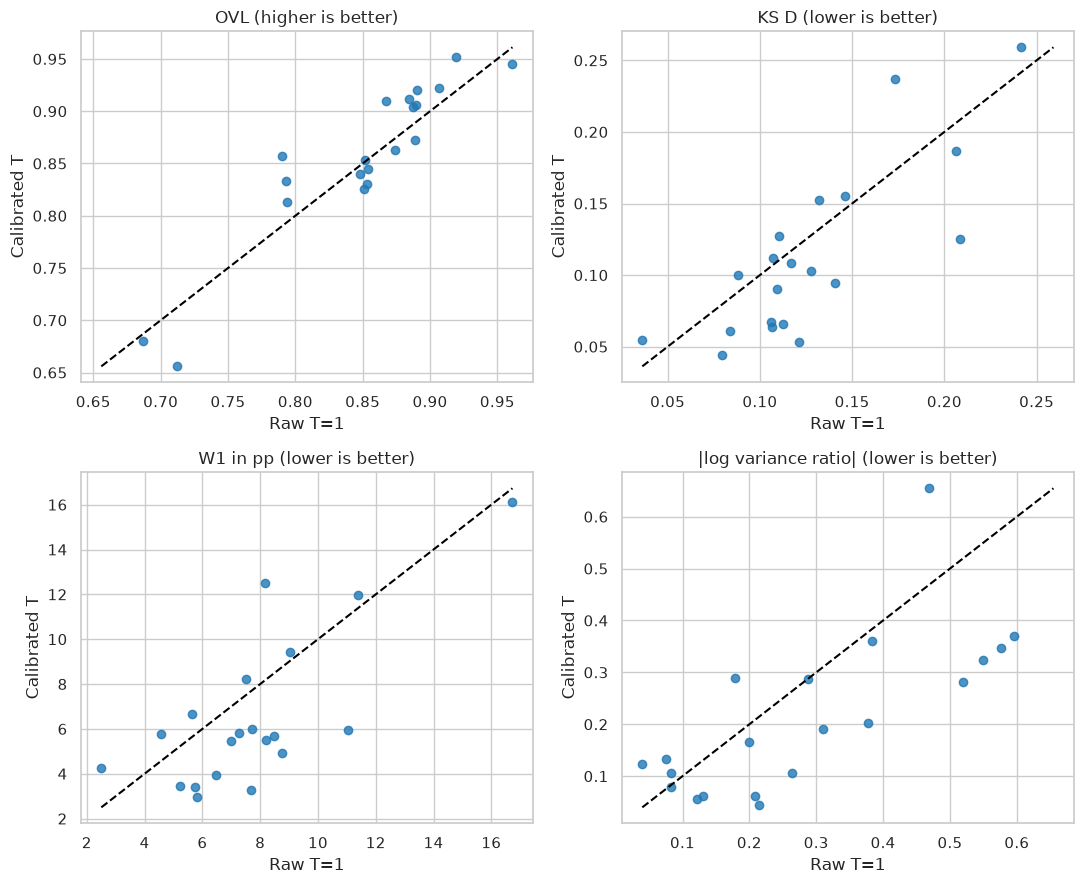

result,item_id,family,raw_T1,calibrated_T_cv,w1_improvement
Largest improvements,fund_research,climate_policy,11.022,5.961,5.061
Largest improvements,teach_gw,climate_policy,7.691,3.288,4.403
Largest improvements,sci_consensus,belief_consensus,8.756,4.907,3.849
Largest improvements,priority_cleanenergy,climate_policy,5.816,2.985,2.831
Largest improvements,harm_dev_countries,concern_harm,8.479,5.696,2.784
Largest improvements,hear_GW_media,engagement_exposure,8.205,5.520,2.685
Largest improvements,worry,concern_harm,6.477,3.965,2.512
Largest improvements,harm_US,concern_harm,5.739,3.430,2.309
Largest regressions,cause_recoded,belief_consensus,8.174,12.516,-4.342
Largest regressions,happening,belief_consensus,2.501,4.272,-1.771


In [11]:
per_item = (
    overall_cv.groupby(["item_id", "family", "arm"])[
        ["ovl", "ks_d", "w1", "abs_log_variance_error"]
    ]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
metric_panels = [
    ("ovl", "OVL (higher is better)"),
    ("ks_d", "KS D (lower is better)"),
    ("w1", "W1 in pp (lower is better)"),
    (
        "abs_log_variance_error",
        "|log variance ratio| (lower is better)",
    ),
]
for axis, (metric, title) in zip(axes.flat, metric_panels, strict=True):
    paired = per_item.pivot(
        index="item_id", columns="arm", values=metric
    ).dropna()
    axis.scatter(
        paired.raw_T1,
        paired.calibrated_T_cv,
        color="tab:blue",
        alpha=0.8,
    )
    low = min(paired.min())
    high = max(paired.max())
    axis.plot([low, high], [low, high], color="black", linestyle="--")
    axis.set(
        xlabel="Raw T=1",
        ylabel="Calibrated T",
        title=title,
    )
plt.tight_layout()
plt.show()

item_w1 = (
    per_item.pivot(
        index=["item_id", "family"],
        columns="arm",
        values="w1",
    )
    .reset_index()
    .rename_axis(columns=None)
)
item_w1["w1_improvement"] = (
    item_w1.raw_T1 - item_w1.calibrated_T_cv
)
display(
    pd.concat(
        [
            item_w1.nlargest(8, "w1_improvement").assign(
                result="Largest improvements"
            ),
            item_w1.nsmallest(8, "w1_improvement").assign(
                result="Largest regressions"
            ),
        ]
    )[
        [
            "result",
            "item_id",
            "family",
            "raw_T1",
            "calibrated_T_cv",
            "w1_improvement",
        ]
    ]
    .style.format(precision=3)
    .hide(axis="index")
)


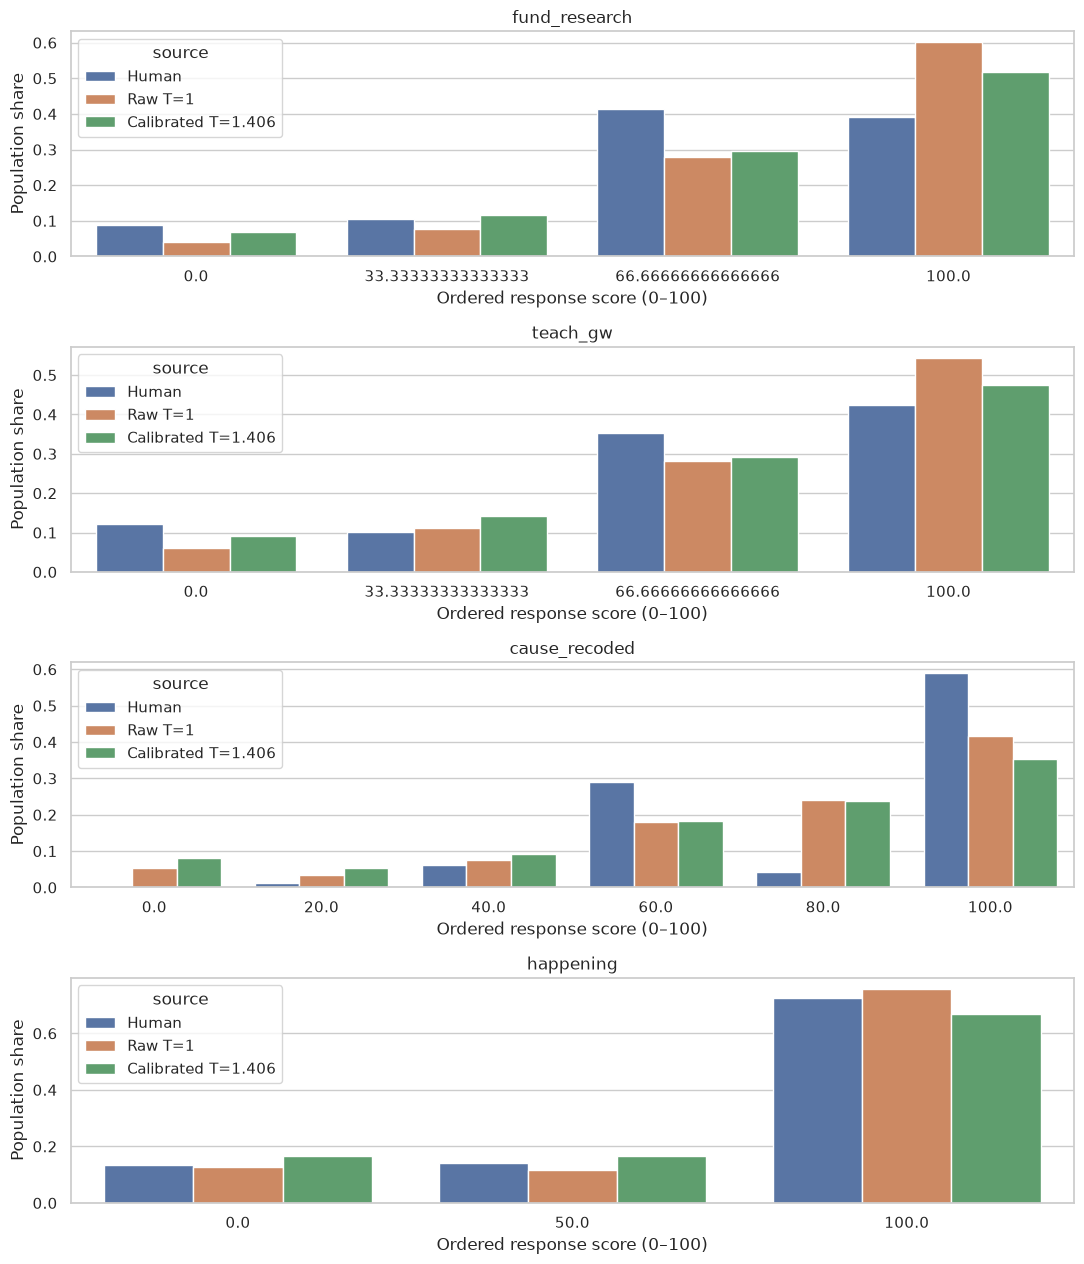

In [12]:
def pooled_distribution_frame(item_ids):
    rows = []
    for item_id in item_ids:
        grid = item_score_grid(item_id)
        distributions = {
            "Human": distribution_shares(
                human_scores,
                item_id,
                human_scores.weight_aggregate,
            ),
            "Raw T=1": distribution_shares(raw_sample, item_id),
            f"Calibrated T={FINAL_TEMPERATURE:.3f}": distribution_shares(
                final_calibrated_sample, item_id
            ),
        }
        for source, shares in distributions.items():
            for score, share in zip(grid, shares, strict=True):
                rows.append(
                    {
                        "item_id": item_id,
                        "score": score,
                        "source": source,
                        "share": share,
                    }
                )
    return pd.DataFrame(rows)

example_items = list(
    dict.fromkeys(
        [
            *item_w1.nlargest(2, "w1_improvement").item_id,
            *item_w1.nsmallest(2, "w1_improvement").item_id,
        ]
    )
)
example_distributions = pooled_distribution_frame(example_items)

fig, axes = plt.subplots(
    len(example_items),
    1,
    figsize=(11, 3.2 * len(example_items)),
    squeeze=False,
)
for axis, item_id in zip(
    axes.flat, example_items, strict=True
):
    sns.barplot(
        data=example_distributions.loc[
            example_distributions.item_id.eq(item_id)
        ],
        x="score",
        y="share",
        hue="source",
        ax=axis,
    )
    axis.set_title(item_id)
    axis.set_xlabel("Ordered response score (0–100)")
    axis.set_ylabel("Population share")
plt.tight_layout()
plt.show()


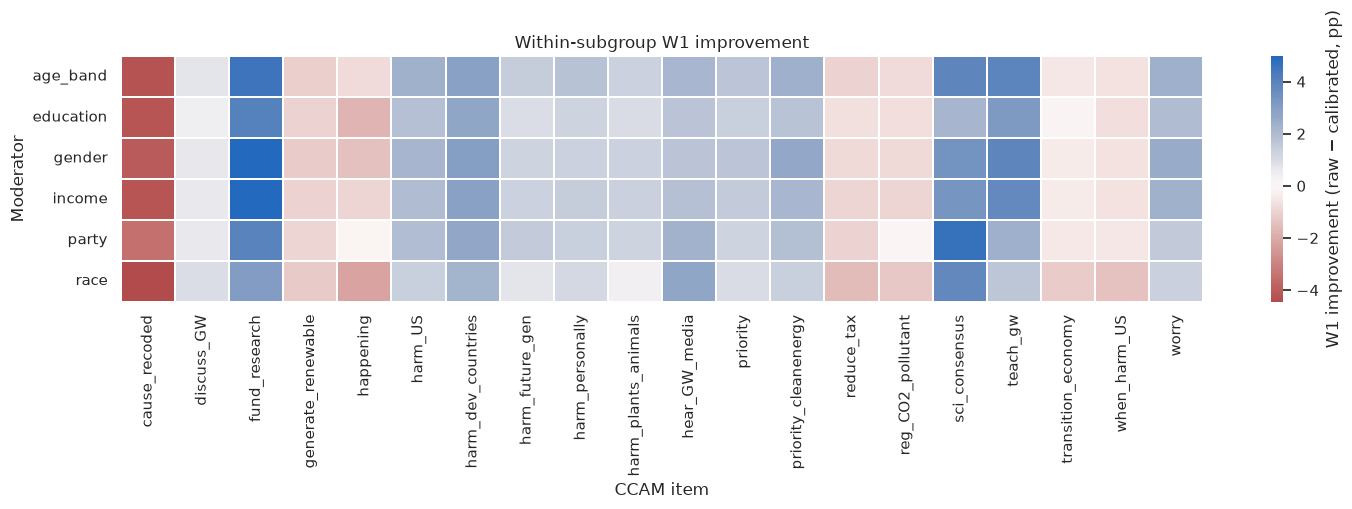

result,moderator,level,item_id,raw_T1,calibrated_T_cv,w1_improvement
Largest improvements,race,Black,sci_consensus,22.532,14.283,8.249
Largest improvements,party,Other,sci_consensus,27.707,20.601,7.107
Largest improvements,gender,Female,sci_consensus,13.766,7.334,6.432
Largest improvements,party,Independent,sci_consensus,10.508,4.353,6.155
Largest improvements,income,"Less than $50,000",sci_consensus,16.787,10.912,5.875
Largest improvements,party,Independent,teach_gw,10.739,4.926,5.813
Largest improvements,race,Black,harm_dev_countries,14.571,8.851,5.720
Largest improvements,party,Other,harm_dev_countries,19.548,13.839,5.710
Largest improvements,education,Some college,teach_gw,10.786,5.188,5.598
Largest improvements,party,Independent,fund_research,10.778,5.322,5.456


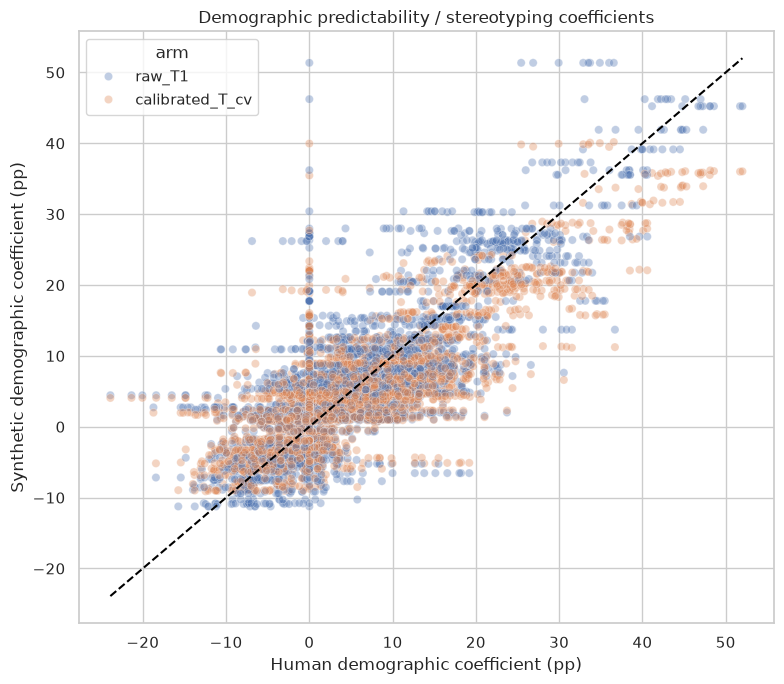

In [13]:
subgroup_w1 = (
    subgroups_cv.loc[~subgroups_cv.skipped]
    .groupby(["moderator", "level", "item_id", "arm"])
    .w1.mean()
    .unstack("arm")
    .dropna()
    .reset_index()
)
subgroup_w1["w1_improvement"] = (
    subgroup_w1.raw_T1 - subgroup_w1.calibrated_T_cv
)

heatmap_data = (
    subgroup_w1.groupby(["moderator", "item_id"])
    .w1_improvement.mean()
    .unstack("item_id")
)
plt.figure(figsize=(15, 5))
sns.heatmap(
    heatmap_data,
    center=0,
    cmap="vlag_r",
    linewidths=0.2,
    cbar_kws={"label": "W1 improvement (raw − calibrated, pp)"},
)
plt.title("Within-subgroup W1 improvement")
plt.xlabel("CCAM item")
plt.ylabel("Moderator")
plt.tight_layout()
plt.show()

display(
    pd.concat(
        [
            subgroup_w1.nlargest(10, "w1_improvement").assign(
                result="Largest improvements"
            ),
            subgroup_w1.nsmallest(10, "w1_improvement").assign(
                result="Largest regressions"
            ),
        ]
    )[
        [
            "result",
            "moderator",
            "level",
            "item_id",
            "raw_T1",
            "calibrated_T_cv",
            "w1_improvement",
        ]
    ]
    .style.format(precision=3)
    .hide(axis="index")
)

coefficient_limits = [
    min(
        coefficients_cv.human_coefficient.min(),
        coefficients_cv.synthetic_coefficient.min(),
    ),
    max(
        coefficients_cv.human_coefficient.max(),
        coefficients_cv.synthetic_coefficient.max(),
    ),
]
plt.figure(figsize=(8, 7))
sns.scatterplot(
    data=coefficients_cv,
    x="human_coefficient",
    y="synthetic_coefficient",
    hue="arm",
    alpha=0.35,
    s=35,
)
plt.plot(
    coefficient_limits,
    coefficient_limits,
    color="black",
    linestyle="--",
)
plt.xlabel("Human demographic coefficient (pp)")
plt.ylabel("Synthetic demographic coefficient (pp)")
plt.title("Demographic predictability / stereotyping coefficients")
plt.tight_layout()
plt.show()


## Verification and interpretation guardrails

The harmonization is intentionally lossy: synthetic Asian and Other race categories map to the CCAM Other category; the synthetic $30,000–$55,999 income band maps wholly below $50,000. Results should be interpreted at these harmonized levels.


In [14]:
# Temperature identity and probability invariants.
for item_id, probabilities in predictions.probabilities.items():
    scaled_at_one = temperature_scale(probabilities, 1.0)
    assert np.allclose(scaled_at_one, probabilities, atol=1e-15, rtol=1e-15)
    assert np.allclose(
        temperature_scale(probabilities, FINAL_TEMPERATURE).sum(axis=1),
        1,
    )
    assert (
        temperature_scale(probabilities, FINAL_TEMPERATURE) >= 0
    ).all()

# Deterministic and paired sampling.
assert raw_sample[list(specs)].equals(
    sampled_score_frame(1.0)[list(specs)]
)
assert set(shared_uniforms) == set(specs)
assert all(len(values) == len(predictions.personas) for values in shared_uniforms.values())

# Distribution identity.
identity_shares = np.array([0.2, 0.3, 0.5])
identity_metrics = categorical_distribution_metrics(
    identity_shares,
    identity_shares,
    np.array([0.0, 50.0, 100.0]),
)
assert np.isclose(identity_metrics["variance_ratio"], 1)
assert np.isclose(identity_metrics["ovl"], 1)
assert np.isclose(identity_metrics["ks_d"], 0)
assert np.isclose(identity_metrics["w1"], 0)

# Every held-out wave is absent from its training tuple.
assert all(
    row.held_out_wave not in row.training_waves
    for row in cv_temperatures.itertuples(index=False)
)
assert all(
    len(row.training_waves) == len(CCAM_WAVES) - 1
    for row in cv_temperatures.itertuples(index=False)
)

# Skipped subgroup rows and parity exclusions are visible.
skipped_subgroups = subgroups_cv.loc[subgroups_cv.skipped]
assert skipped_subgroups.skip_reason.notna().all()
assert (
    baselines_cv.loc[
        baselines_cv.n_skipped.gt(0), "groups_skipped"
    ]
    .fillna("")
    .str.len()
    .gt(0)
    .all()
)

# Repository-root discovery works from both supported launch locations.
assert find_repository_root(ROOT) == ROOT
assert find_repository_root(ROOT / "jupyter_scripts") == ROOT

print("All verification checks passed.")
print(
    f"Primary result uses {len(cv_temperatures)} held-out waves, "
    f"one fixed paired sampling seed ({SAMPLING_SEED}), "
    f"and survey-weighted human targets."
)


All verification checks passed.
Primary result uses 10 held-out waves, one fixed paired sampling seed (20260804), and survey-weighted human targets.


### Reading the comparison

- A positive **improvement** column always favors calibrated sampling.
- Cross-validated rows are the primary evidence; pooled rows describe the final all-wave temperature.
- Variance ratios themselves are descriptive. Their scorecard comparison uses absolute log distance from 1 so equal over- and under-dispersion are penalized symmetrically.
- Because only one shared draw is used, small raw-versus-calibrated differences should not be interpreted as Monte Carlo-stable without a multi-seed sensitivity analysis.
